In [1]:
import sys
print(sys.executable)

C:\Users\saite\Downloads\statistics-practical-python\.venv\Scripts\python.exe


In [2]:
import numpy
import pandas
import matplotlib
import seaborn
import scipy

print("Everything is working!")

Everything is working!


In [3]:
# ============================================================
# STATISTICS PRACTICAL IMPLEMENTATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

np.random.seed(42)


# ============================================================
# 1. CREATE SYNTHETIC DATA
# ============================================================

n = 1000

df = pd.DataFrame({
    "customer_id": range(1, n + 1),
    "age": np.clip(
        np.random.normal(40, 12, n).astype(int),
        18, 80
    ),
    "annual_income": np.random.normal(
        800000, 250000, n
    ),
    "policy_premium": np.random.normal(
        25000, 7000, n
    ),
    "claim_amount": np.random.exponential(
        50000, n
    ),
    "number_of_claims": np.random.poisson(
        1.2, n
    ),
    "health_score": np.random.normal(
        70, 12, n
    ),
    "policy_tenure": np.random.randint(
        1, 15, n
    )
})

# Prevent impossible values
df["annual_income"] = df["annual_income"].clip(lower=100000)
df["policy_premium"] = df["policy_premium"].clip(lower=5000)
df["health_score"] = df["health_score"].clip(0, 100)


# ============================================================
# 2. POPULATION VS SAMPLE
# ============================================================

population = df["annual_income"]

sample = df["annual_income"].sample(
    n=100,
    random_state=42
)

population_mean = population.mean()
sample_mean = sample.mean()


# ============================================================
# 3. SAMPLING TECHNIQUES
# ============================================================

simple_random_sample = df.sample(
    n=100,
    random_state=42
)

systematic_sample = df.iloc[::10]

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 45, 60, 100],
    labels=[
        "Young",
        "Middle",
        "Senior",
        "Older"
    ]
)

stratified_sample = (
    df.groupby(
        "age_group",
        observed=True
    )
    .sample(
        frac=0.10,
        random_state=42
    )
)


# ============================================================
# 4. MEAN / MEDIAN / MODE
# ============================================================

claim_mean = df["claim_amount"].mean()
claim_median = df["claim_amount"].median()
claim_mode = df["number_of_claims"].mode()[0]


# ============================================================
# 5. VARIANCE
# ============================================================

income_variance = df["annual_income"].var()


# ============================================================
# 6. STANDARD DEVIATION
# ============================================================

income_std = df["annual_income"].std()


# ============================================================
# 7. COVARIANCE
# ============================================================

covariance = df[
    ["annual_income", "policy_premium"]
].cov()


# ============================================================
# 8. CORRELATION
# ============================================================

correlation = df[
    ["annual_income", "policy_premium"]
].corr()


# ============================================================
# 9. PROBABILITY BASICS
# ============================================================

high_claim = df["claim_amount"] > 100000

probability_high_claim = high_claim.mean()


# ============================================================
# 10. CONDITIONAL PROBABILITY
# ============================================================

previous_claims_gt_2 = (
    df["number_of_claims"] > 2
)

probability_high_claim_given_previous_claims = (
    df.loc[
        previous_claims_gt_2,
        "claim_amount"
    ].gt(100000).mean()
)


# ============================================================
# 11. BAYES THEOREM
# ============================================================

A = df["claim_amount"] > 100000
B = df["number_of_claims"] > 2

P_A = A.mean()
P_B_given_A = B[A].mean()
P_B = B.mean()

bayes_probability = (
    P_B_given_A * P_A
) / P_B


# ============================================================
# 12. NORMAL DISTRIBUTION
# ============================================================

income_mean = df["annual_income"].mean()
income_std = df["annual_income"].std()


# ============================================================
# 13. CENTRAL LIMIT THEOREM
# ============================================================

sample_means = []

for i in range(1000):

    sample = df["claim_amount"].sample(
        n=30,
        random_state=i
    )

    sample_means.append(
        sample.mean()
    )

sample_means = np.array(sample_means)


# ============================================================
# 14. Z SCORE
# ============================================================

df["income_zscore"] = stats.zscore(
    df["annual_income"]
)


# ============================================================
# 15. OUTLIERS — IQR
# ============================================================

Q1 = df["claim_amount"].quantile(0.25)
Q3 = df["claim_amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["claim_amount"] < lower_bound) |
    (df["claim_amount"] > upper_bound)
]


# ============================================================
# 16. CONFIDENCE INTERVAL
# ============================================================

ci_sample = df["annual_income"].sample(
    n=100,
    random_state=42
)

ci_mean = ci_sample.mean()

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(ci_sample) - 1,
    loc=ci_mean,
    scale=stats.sem(ci_sample)
)


# ============================================================
# 17. SAVE DATA
# ============================================================

df.to_csv(
    "../data/synthetic_customer_data.csv",
    index=False
)

print("Analysis completed.")

Analysis completed.


In [4]:
# ============================================================
# RESULTS
# ============================================================

print("=" * 60)
print("POPULATION VS SAMPLE")
print("=" * 60)

print(f"Population mean : ₹{population_mean:,.2f}")
print(f"Sample mean     : ₹{sample_mean:,.2f}")


print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

print(f"Claim mean      : ₹{claim_mean:,.2f}")
print(f"Claim median    : ₹{claim_median:,.2f}")
print(f"Claim mode      : {claim_mode}")
print(f"Income variance : {income_variance:,.2f}")
print(f"Income std      : ₹{income_std:,.2f}")


print("\n" + "=" * 60)
print("PROBABILITY")
print("=" * 60)

print(
    f"P(Claim > ₹100K): "
    f"{probability_high_claim:.4f}"
)

print(
    f"P(Claim > ₹100K | Previous Claims > 2): "
    f"{probability_high_claim_given_previous_claims:.4f}"
)


print("\n" + "=" * 60)
print("BAYES THEOREM")
print("=" * 60)

print(
    f"P(Previous Claims > 2 | Claim > ₹100K): "
    f"{P_B_given_A:.4f}"
)

print(
    f"Bayes calculated probability: "
    f"{bayes_probability:.4f}"
)


print("\n" + "=" * 60)
print("CORRELATION")
print("=" * 60)

print(correlation)


print("\n" + "=" * 60)
print("CENTRAL LIMIT THEOREM")
print("=" * 60)

print(
    f"Original claim mean       : "
    f"₹{df['claim_amount'].mean():,.2f}"
)

print(
    f"Mean of sample means      : "
    f"₹{sample_means.mean():,.2f}"
)

print(
    f"Std of sample means       : "
    f"₹{sample_means.std():,.2f}"
)


print("\n" + "=" * 60)
print("Z SCORE / OUTLIERS")
print("=" * 60)

print(
    f"Number of outliers: "
    f"{len(outliers)}"
)


print("\n" + "=" * 60)
print("95% CONFIDENCE INTERVAL")
print("=" * 60)

print(
    f"Sample mean: ₹{ci_mean:,.2f}"
)

print(
    f"95% CI: "
    f"₹{confidence_interval[0]:,.2f}"
    f" - "
    f"₹{confidence_interval[1]:,.2f}"
)

POPULATION VS SAMPLE
Population mean : ₹817,828.76
Sample mean     : ₹807,391.35

DESCRIPTIVE STATISTICS
Claim mean      : ₹48,368.54
Claim median    : ₹33,038.69
Claim mode      : 1
Income variance : 62,006,988,426.64
Income std      : ₹249,012.02

PROBABILITY
P(Claim > ₹100K): 0.1240
P(Claim > ₹100K | Previous Claims > 2): 0.1589

BAYES THEOREM
P(Previous Claims > 2 | Claim > ₹100K): 0.1371
Bayes calculated probability: 0.1589

CORRELATION
                annual_income  policy_premium
annual_income        1.000000       -0.011125
policy_premium      -0.011125        1.000000

CENTRAL LIMIT THEOREM
Original claim mean       : ₹48,368.54
Mean of sample means      : ₹48,497.72
Std of sample means       : ₹8,841.40

Z SCORE / OUTLIERS
Number of outliers: 54

95% CONFIDENCE INTERVAL
Sample mean: ₹807,391.35
95% CI: ₹755,374.75 - ₹859,407.95


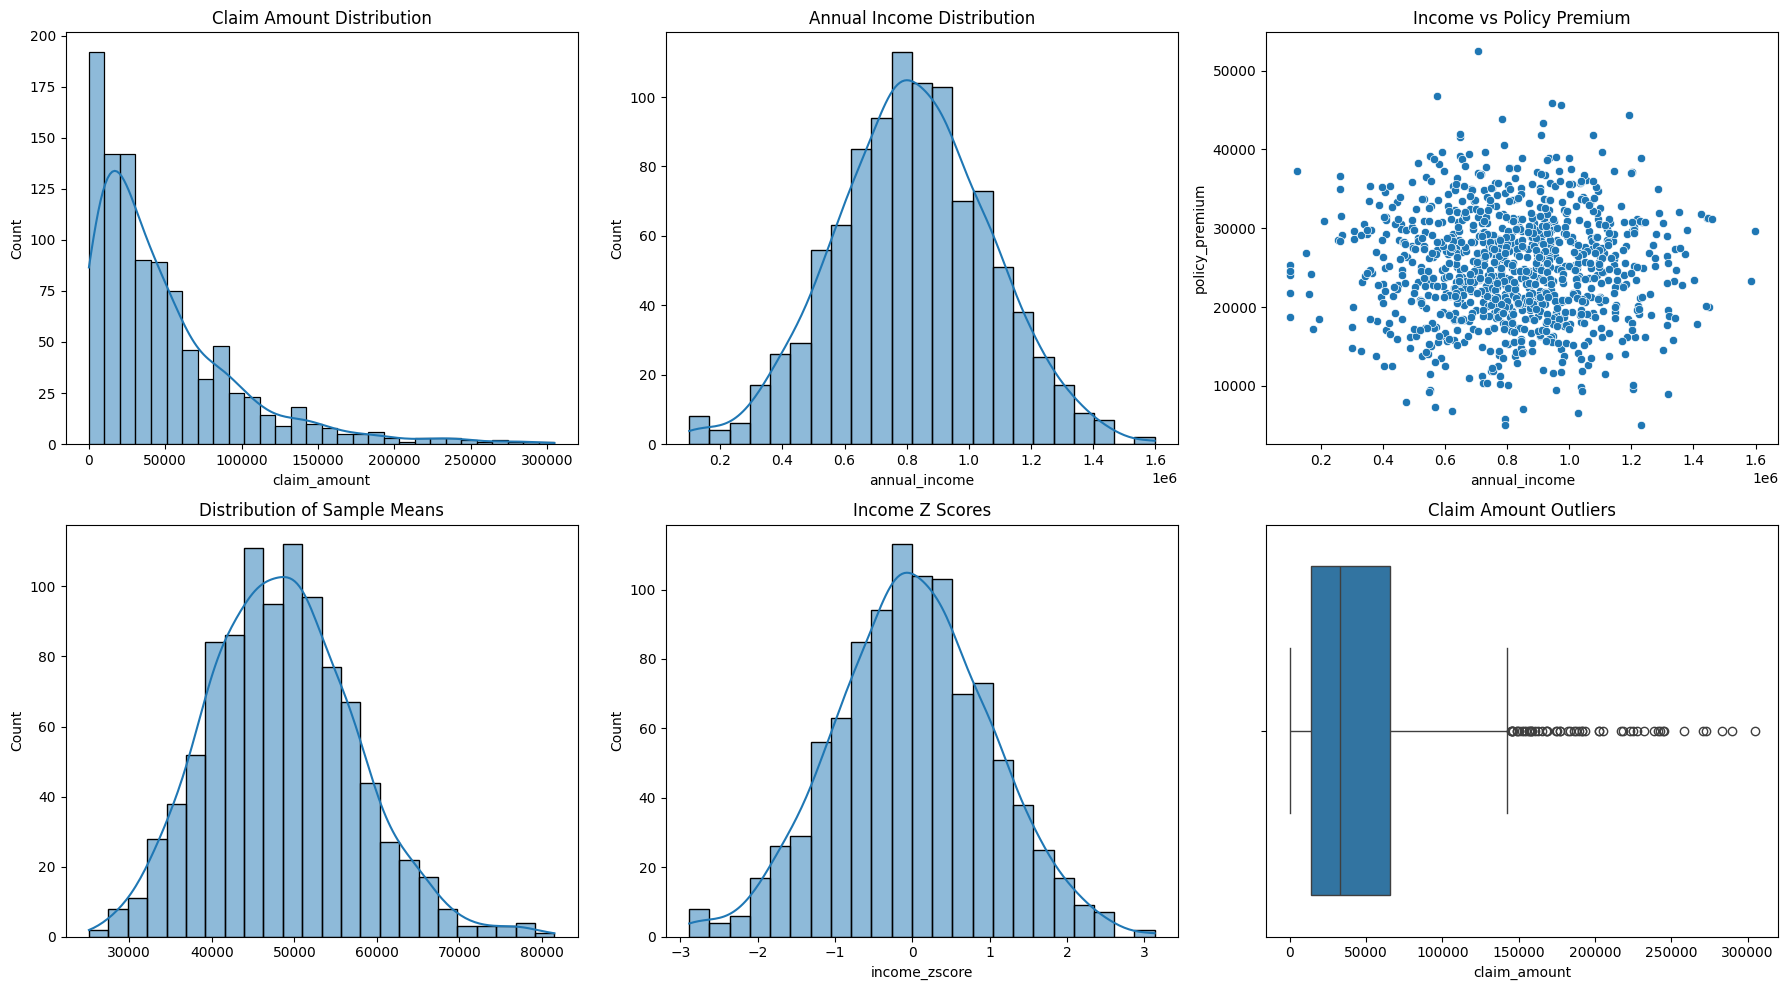

In [5]:
# ============================================================
# FIGURES
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Claim distribution
sns.histplot(
    df["claim_amount"],
    kde=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title(
    "Claim Amount Distribution"
)

# 2. Income distribution
sns.histplot(
    df["annual_income"],
    kde=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title(
    "Annual Income Distribution"
)

# 3. Income vs premium
sns.scatterplot(
    data=df,
    x="annual_income",
    y="policy_premium",
    ax=axes[0, 2]
)
axes[0, 2].set_title(
    "Income vs Policy Premium"
)

# 4. CLT
sns.histplot(
    sample_means,
    kde=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title(
    "Distribution of Sample Means"
)

# 5. Z scores
sns.histplot(
    df["income_zscore"],
    kde=True,
    ax=axes[1, 1]
)
axes[1, 1].set_title(
    "Income Z Scores"
)

# 6. Outliers
sns.boxplot(
    x=df["claim_amount"],
    ax=axes[1, 2]
)
axes[1, 2].set_title(
    "Claim Amount Outliers"
)

plt.tight_layout()

plt.savefig(
    "../outputs/statistics_figures.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()